# Building an RNN from Scratch

**What we'll build:** A complete Recurrent Neural Network (RNN) implemented from basic PyTorch operations, trained to predict the next character in a sequence.

**Why it matters:** RNNs were the first successful architecture for sequence modeling. Understanding how they work from scratch reveals the core mechanism behind modern sequence models.

**What intuitions we'll develop:**
- How networks maintain "memory" through hidden states
- Why matrix multiplications are the building blocks of neural sequence processing
- How gradients flow through time (backpropagation through time)
- The fundamental challenge: vanishing gradients

## 1. Setup

First, let's import our dependencies and configure the environment for reproducibility.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from aiml_notebooks import create_dataset, create_dataloaders, get_device, set_seed

%load_ext autoreload
%autoreload 2

Set random seed for reproducibility across all experiments.

In [2]:
set_seed(42)

Configure device for optimal performance (GPU if available).

In [3]:
device = get_device()
print(f"Using device: {device}")

Using CUDA GPU: NVIDIA GeForce RTX 4090
Using device: cuda


## 2. The Problem: Sequences Need Memory

Consider predicting the next character in a name. To predict the 't' in "Charlotte", the network needs to remember all previous characters: 'C', 'h', 'a', 'r', 'l', 'o'.

**Traditional neural networks** process each input independently — they have no memory.

**RNNs solve this** by maintaining a **hidden state** that carries information forward through the sequence.

Let's load a simple dataset of names to work with.

In [4]:
full_dataset, train_dataset, val_dataset = create_dataset("names", splits=[0.9, 0.1])
tokenizer = full_dataset.tokenizer

print(f"Vocabulary size: {tokenizer.vocab_size}")
print(f"Characters: {tokenizer.chars}")
print(f"Training examples: {len(train_dataset)}")
print(f"Validation examples: {len(val_dataset)}")

Vocabulary size: 27
Characters: ['.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Training examples: 28829
Validation examples: 3204


Let's look at a few examples to understand the data structure.

In [5]:
# Show a few examples from the dataset
sample_names = full_dataset.get_texts()[:3]
for text in sample_names:
    tokens = tokenizer.encode(text)
    print(f"Name: {text:15} → Tokens: {tokens}")

Name: emma            → Tokens: [5, 13, 13, 1]
Name: olivia          → Tokens: [15, 12, 9, 22, 9, 1]
Name: ava             → Tokens: [1, 22, 1]


## 3. RNN Intuition: Memory Through Hidden State

An RNN processes sequences one element at a time. At each step, it:
1. Takes the **current input** (e.g., character)
2. Combines it with the **previous hidden state** (memory)
3. Produces a **new hidden state** (updated memory)
4. Optionally produces an **output** (e.g., next character prediction)

The hidden state acts as the network's "memory" of what it has seen so far.

### The RNN Formula

At each time step $t$, the RNN computes:

$$h_t = \tanh(W_{ih} x_t + W_{hh} h_{t-1} + b_h)$$

Where:
- $x_t$ = current input (embedding of current character)
- $h_{t-1}$ = previous hidden state (memory from previous steps)
- $h_t$ = new hidden state (updated memory)
- $W_{ih}$ = weights for input-to-hidden transformation
- $W_{hh}$ = weights for hidden-to-hidden transformation
- $b_h$ = bias term
- $\tanh$ = activation function (squashes values to [-1, 1])

The key insight: we're combining the **current input** with **past information** at every step.

## 4. Building Block 1: The RNN Cell

Let's implement a single RNN cell — the fundamental unit that processes one time step.

In [6]:
class RNNCell(nn.Module):
    """Single RNN cell: processes one time step."""
    
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        
        # Input-to-hidden transformation
        self.W_ih = nn.Linear(input_size, hidden_size, bias=False)
        
        # Hidden-to-hidden transformation
        self.W_hh = nn.Linear(hidden_size, hidden_size, bias=False)
        
        # Bias term
        self.bias = nn.Parameter(torch.zeros(hidden_size))
    
    def forward(self, x, h_prev):
        """
        Args:
            x: (batch_size, input_size) - current input
            h_prev: (batch_size, hidden_size) - previous hidden state
        
        Returns:
            h_new: (batch_size, hidden_size) - new hidden state
        """
        h_new = torch.tanh(self.W_ih(x) + self.W_hh(h_prev) + self.bias)
        return h_new

# Create a simple RNN cell
input_size = 10
hidden_size = 20
cell = RNNCell(input_size, hidden_size)

print(f"RNN Cell parameters:")
print(f"  W_ih: {input_size} × {hidden_size} = {input_size * hidden_size}")
print(f"  W_hh: {hidden_size} × {hidden_size} = {hidden_size * hidden_size}")
print(f"  bias: {hidden_size}")
print(f"  Total: {sum(p.numel() for p in cell.parameters())} parameters")

RNN Cell parameters:
  W_ih: 10 × 20 = 200
  W_hh: 20 × 20 = 400
  bias: 20
  Total: 620 parameters


Let's test the RNN cell with a simple example to see how it transforms inputs.

In [7]:
# Create dummy input and initial hidden state
batch_size = 2
x = torch.randn(batch_size, input_size)
h_prev = torch.zeros(batch_size, hidden_size)  # Initial hidden state

# Process one time step
h_new = cell(x, h_prev)

print(f"Input shape: {x.shape}")
print(f"Previous hidden state shape: {h_prev.shape}")
print(f"New hidden state shape: {h_new.shape}")
print(f"\nHidden state range: [{h_new.min():.3f}, {h_new.max():.3f}]")
print("(Note: tanh squashes values to [-1, 1])")

Input shape: torch.Size([2, 10])
Previous hidden state shape: torch.Size([2, 20])
New hidden state shape: torch.Size([2, 20])

Hidden state range: [-0.825, 0.732]
(Note: tanh squashes values to [-1, 1])


## 5. Building Block 2: Processing a Sequence

An RNN cell processes **one** time step. To process a **sequence**, we apply the cell repeatedly, feeding the output hidden state back as input.

This is called **unrolling** the RNN through time.

In [8]:
def process_sequence(cell, sequence, h_init):
    """
    Process a sequence through an RNN cell.
    
    Args:
        cell: RNNCell instance
        sequence: (seq_len, batch_size, input_size)
        h_init: (batch_size, hidden_size) - initial hidden state
    
    Returns:
        hidden_states: List of hidden states at each time step
    """
    hidden_states = []
    h = h_init
    
    for x_t in sequence:
        h = cell(x_t, h)  # Update hidden state
        hidden_states.append(h)
    
    return hidden_states

# Test with a sequence of length 5
seq_len = 5
sequence = torch.randn(seq_len, batch_size, input_size)
h_init = torch.zeros(batch_size, hidden_size)

hidden_states = process_sequence(cell, sequence, h_init)

print(f"Sequence length: {seq_len}")
print(f"Number of hidden states: {len(hidden_states)}")
print(f"Each hidden state shape: {hidden_states[0].shape}")

Sequence length: 5
Number of hidden states: 5
Each hidden state shape: torch.Size([2, 20])


Let's visualize how the hidden state evolves through the sequence.

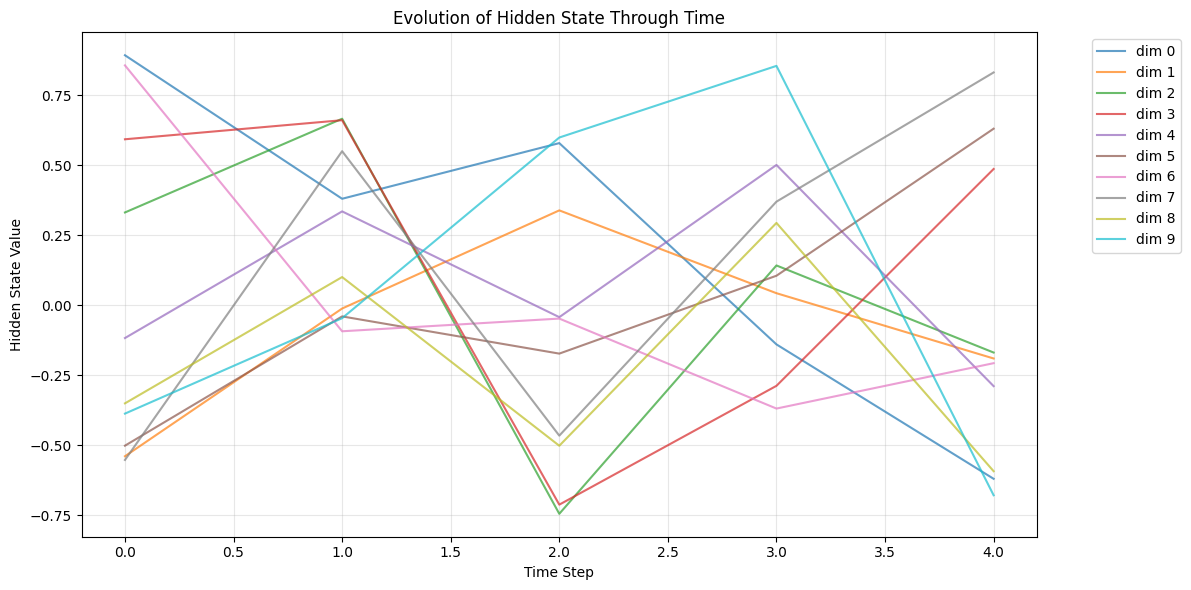

Each line shows how one dimension of the hidden state changes as we process the sequence.


In [9]:
# Convert hidden states to numpy for visualization
hidden_states_np = torch.stack(hidden_states).detach().numpy()

# Plot the evolution of the first 10 dimensions of the hidden state
plt.figure(figsize=(12, 6))
for dim in range(min(10, hidden_size)):
    plt.plot(hidden_states_np[:, 0, dim], label=f'dim {dim}', alpha=0.7)

plt.xlabel('Time Step')
plt.ylabel('Hidden State Value')
plt.title('Evolution of Hidden State Through Time')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Each line shows how one dimension of the hidden state changes as we process the sequence.")

## 6. Building Block 3: Complete RNN with Output Layer

Now let's build a complete RNN that:
1. Embeds input tokens
2. Processes sequences with RNN cell
3. Projects hidden states to output predictions

In [10]:
class SimpleRNN(nn.Module):
    """Complete RNN for character-level language modeling."""
    
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        
        # Embedding layer: converts token indices to dense vectors
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # RNN cell
        self.rnn_cell = RNNCell(embedding_dim, hidden_size)
        
        # Output layer: projects hidden state to vocabulary
        self.output_layer = nn.Linear(hidden_size, vocab_size)
    
    def forward(self, x, h=None):
        """
        Args:
            x: (batch_size, seq_len) - input token indices
            h: (batch_size, hidden_size) - initial hidden state (optional)
        
        Returns:
            logits: (batch_size, seq_len, vocab_size) - predictions at each step
            h_final: (batch_size, hidden_size) - final hidden state
        """
        batch_size, seq_len = x.shape
        
        # Initialize hidden state if not provided
        if h is None:
            h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        
        # Embed tokens
        embeddings = self.embedding(x)  # (batch_size, seq_len, embedding_dim)
        
        # Process sequence
        outputs = []
        for t in range(seq_len):
            x_t = embeddings[:, t, :]  # Current time step
            h = self.rnn_cell(x_t, h)  # Update hidden state
            output = self.output_layer(h)  # Project to vocabulary
            outputs.append(output)
        
        # Stack outputs
        logits = torch.stack(outputs, dim=1)  # (batch_size, seq_len, vocab_size)
        
        return logits, h

# Create model
vocab_size = tokenizer.vocab_size
embedding_dim = 16
hidden_size = 64

model = SimpleRNN(vocab_size, embedding_dim, hidden_size).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model architecture:")
print(f"  Vocabulary: {vocab_size}")
print(f"  Embedding dim: {embedding_dim}")
print(f"  Hidden size: {hidden_size}")
print(f"  Total parameters: {total_params:,}")

Model architecture:
  Vocabulary: 27
  Embedding dim: 16
  Hidden size: 64
  Total parameters: 7,371


Let's test the model with a sample input to verify the shapes.

In [11]:
# Create dummy batch
test_batch_size = 4
test_seq_len = 10
test_input = torch.randint(0, vocab_size, (test_batch_size, test_seq_len)).to(device)

# Forward pass
logits, h_final = model(test_input)

print(f"Input shape: {test_input.shape}")
print(f"Output logits shape: {logits.shape}")
print(f"Final hidden state shape: {h_final.shape}")
print(f"\nFor each of {test_batch_size} sequences:")
print(f"  - {test_seq_len} positions")
print(f"  - {vocab_size} vocabulary predictions at each position")

Input shape: torch.Size([4, 10])
Output logits shape: torch.Size([4, 10, 27])
Final hidden state shape: torch.Size([4, 64])

For each of 4 sequences:
  - 10 positions
  - 27 vocabulary predictions at each position


## 7. Training Setup: Loss and Optimization

For character prediction, we use **cross-entropy loss** to compare predicted probabilities with true next characters.

The loss tells us: "How wrong were our predictions?"

In [12]:
def compute_loss(model, x, y):
    """
    Compute cross-entropy loss for sequence prediction.
    
    Args:
        model: SimpleRNN instance
        x: (batch_size, seq_len) - input sequences
        y: (batch_size, seq_len) - target sequences (shifted by 1)
    
    Returns:
        loss: scalar tensor
    """
    logits, _ = model(x)
    
    # Reshape for cross-entropy: (batch * seq_len, vocab_size) and (batch * seq_len,)
    logits_flat = logits.reshape(-1, logits.size(-1))
    y_flat = y.reshape(-1)
    
    loss = F.cross_entropy(logits_flat, y_flat)
    return loss

# Test loss computation
test_targets = torch.randint(0, vocab_size, (test_batch_size, test_seq_len)).to(device)
test_loss = compute_loss(model, test_input, test_targets)

print(f"Test loss: {test_loss.item():.4f}")
print(f"Random baseline: {np.log(vocab_size):.4f}")
print("\n(Untrained model should be close to random baseline)")

Test loss: 3.3312
Random baseline: 3.2958

(Untrained model should be close to random baseline)


Create data loaders to efficiently batch and iterate through our dataset.

In [13]:
batch_size = 128
train_loader, val_loader = create_dataloaders(
    train_dataset, 
    val_dataset, 
    batch_size=batch_size
)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

# Peek at one batch
sample_batch = next(iter(train_loader))
print(f"\nSample batch shape: {sample_batch[0].shape}")
print(f"First sequence: {sample_batch[0][0].tolist()}")
print(f"Decoded: {tokenizer.decode(sample_batch[0][0].tolist())}")

Training batches: 226
Validation batches: 26

Sample batch shape: torch.Size([128, 10])
First sequence: [0, 10, 1, 14, 14, 5, 25, 0, 0, 0]
Decoded: .janney...


## 8. Training Loop: Teaching the RNN

Now we'll train the RNN to predict the next character in a sequence. The training process:
1. Forward pass: predict next characters
2. Compute loss: compare predictions to true characters
3. Backward pass: compute gradients (backpropagation through time)
4. Update weights: adjust parameters to improve predictions

In [14]:
def train_epoch(model, train_loader, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        loss = compute_loss(model, x, y)
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping (prevents exploding gradients)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Update weights
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)

def evaluate(model, val_loader, device):
    """Evaluate on validation set."""
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            loss = compute_loss(model, x, y)
            total_loss += loss.item()
    
    return total_loss / len(val_loader)

print("Training functions defined.")
print("Note: Gradient clipping prevents exploding gradients during backprop through time.")

Training functions defined.
Note: Gradient clipping prevents exploding gradients during backprop through time.


Initialize the optimizer (Adam with learning rate 0.001).

In [15]:
learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print(f"Optimizer: Adam")
print(f"Learning rate: {learning_rate}")
print(f"Parameters to optimize: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Optimizer: Adam
Learning rate: 0.001
Parameters to optimize: 7,371


Train the model for multiple epochs and track the loss.

In [16]:
num_epochs = 20
train_losses = []
val_losses = []

print("Training...")
for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, device)
    val_loss = evaluate(model, val_loader, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

print("\nTraining complete!")

Training...


Epoch  5/20 | Train Loss: 2.1765 | Val Loss: 2.1756


Epoch 10/20 | Train Loss: 2.1200 | Val Loss: 2.1411


Epoch 15/20 | Train Loss: 2.0934 | Val Loss: 2.1243


Epoch 20/20 | Train Loss: 2.0753 | Val Loss: 2.1118

Training complete!


Visualize the training progress to see how the model learned.

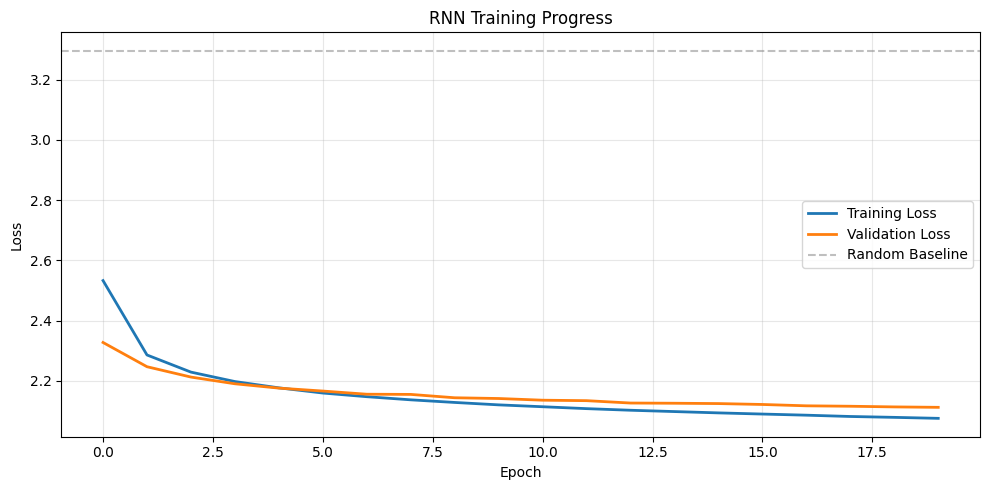

Initial train loss: 2.5326
Final train loss: 2.0753
Improvement: 18.1%


In [17]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.axhline(y=np.log(vocab_size), color='gray', linestyle='--', label='Random Baseline', alpha=0.5)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RNN Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial train loss: {train_losses[0]:.4f}")
print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Improvement: {((train_losses[0] - train_losses[-1]) / train_losses[0] * 100):.1f}%")

## 9. Text Generation: Sampling from the RNN

Now that the model is trained, we can use it to generate new names by:
1. Starting with a special token
2. Predicting the next character
3. Feeding that character back as input
4. Repeating until we generate an end token

In [18]:
@torch.no_grad()
def generate(model, tokenizer, device, max_length=20, temperature=1.0):
    """
    Generate a name from the trained RNN.
    
    Args:
        model: Trained SimpleRNN
        tokenizer: Character tokenizer
        device: torch.device
        max_length: Maximum sequence length
        temperature: Sampling temperature (higher = more random)
    
    Returns:
        generated_text: str
    """
    model.eval()
    
    # Start with special start token (assumed to be index 0)
    generated = [0]
    h = None
    
    for _ in range(max_length):
        # Prepare input
        x = torch.tensor([generated[-1]], device=device).unsqueeze(0)  # (1, 1)
        
        # Forward pass
        logits, h = model(x, h)
        logits = logits[0, -1, :]  # Get last position logits
        
        # Apply temperature
        logits = logits / temperature
        
        # Sample next token
        probs = F.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1).item()
        
        generated.append(next_token)
        
        # Stop if we generate end token (assumed to be index 0)
        if next_token == 0:
            break
    
    # Decode
    generated_text = tokenizer.decode(generated)
    return generated_text.strip()

print("Generation function defined.")

Generation function defined.


Generate some sample names to see what the RNN learned.

In [19]:
print("Generated names:\n")
for i in range(10):
    name = generate(model, tokenizer, device, temperature=0.8)
    print(f"  {i+1:2d}. {name}")

Generated names:



   1. .kritarik.
   2. .vilanie.
   3. .dagar.
   4. .everie.
   5. .irisha.
   6. .onaire.
   7. .live.
   8. .breigh.


   9. .margemin.
  10. .wistie.


## 10. Temperature: Controlling Randomness

The **temperature** parameter controls how random the generation is:
- **Low temperature (0.5)**: More deterministic, safe choices
- **High temperature (1.5)**: More random, creative choices

Mathematically: $\text{probs} = \text{softmax}(\text{logits} / T)$

In [20]:
temperatures = [0.5, 0.8, 1.0, 1.5]

for temp in temperatures:
    print(f"\nTemperature = {temp}:")
    for i in range(5):
        name = generate(model, tokenizer, device, temperature=temp)
        print(f"  {name}")


Temperature = 0.5:
  .anny.
  .kulina.
  .maris.
  .smilayah.
  .marian.

Temperature = 0.8:
  .marty.
  .kahayah.


  .trenton.
  .kenzin.
  .edilyn.

Temperature = 1.0:
  .kehamar.
  .neeza.
  .rryn.
  .arta.
  .joshia.

Temperature = 1.5:
  .tahyriz.
  .zirojig.
  .eenneq.
  .zaiahna.
  .ivianarith.


Visualize how temperature affects the probability distribution.

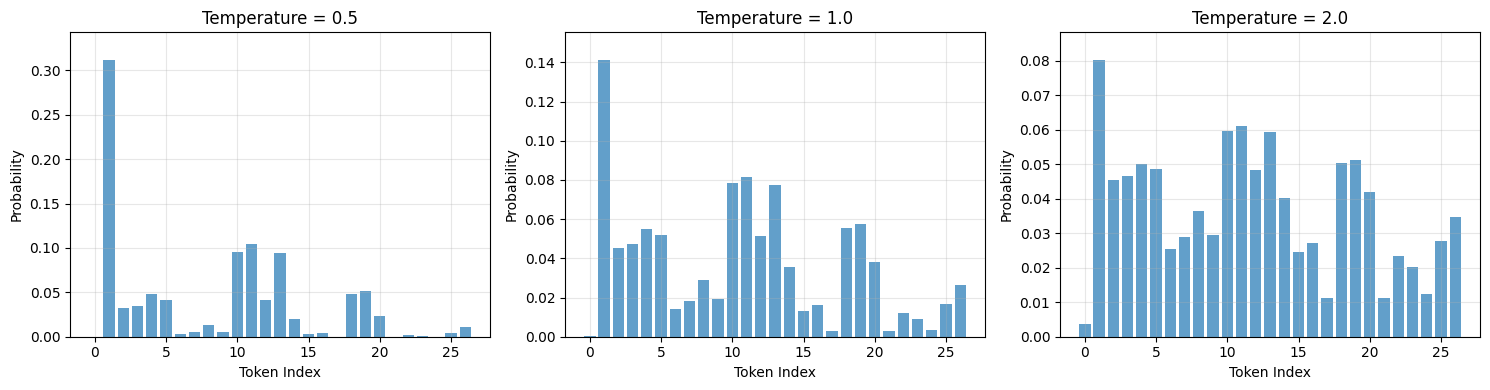

Lower temperature → Peaky distribution (more deterministic)
Higher temperature → Flat distribution (more random)


In [21]:
# Get sample logits from model
sample_input = torch.tensor([[0]], device=device)
logits, _ = model(sample_input)
logits = logits[0, 0, :].detach().cpu()

# Apply different temperatures
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
temps = [0.5, 1.0, 2.0]

for ax, temp in zip(axes, temps):
    probs = F.softmax(logits / temp, dim=-1).numpy()
    ax.bar(range(len(probs)), probs, alpha=0.7)
    ax.set_title(f'Temperature = {temp}')
    ax.set_xlabel('Token Index')
    ax.set_ylabel('Probability')
    ax.set_ylim(0, max(probs) * 1.1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Lower temperature → Peaky distribution (more deterministic)")
print("Higher temperature → Flat distribution (more random)")

## 11. Analyzing Hidden States

Let's peek inside the RNN to see how hidden states encode information about the sequence.

In [22]:
@torch.no_grad()
def get_hidden_states(model, text, tokenizer, device):
    """Extract hidden states for each character in text."""
    model.eval()
    
    tokens = tokenizer.encode(text)
    x = torch.tensor([tokens], device=device)
    
    # Get embeddings
    embeddings = model.embedding(x)
    
    # Process sequence and collect hidden states
    batch_size, seq_len = x.shape
    h = torch.zeros(batch_size, model.hidden_size, device=device)
    hidden_states = []
    
    for t in range(seq_len):
        x_t = embeddings[:, t, :]
        h = model.rnn_cell(x_t, h)
        hidden_states.append(h.cpu())
    
    return torch.stack(hidden_states).squeeze(1).numpy(), tokens

# Analyze a sample name
sample_name = "charlotte"
hidden_states, tokens = get_hidden_states(model, sample_name, tokenizer, device)

print(f"Analyzing: {sample_name}")
print(f"Tokens: {tokens}")
print(f"Hidden states shape: {hidden_states.shape} (seq_len × hidden_size)")

Analyzing: charlotte
Tokens: [3, 8, 1, 18, 12, 15, 20, 20, 5]
Hidden states shape: (9, 64) (seq_len × hidden_size)


Visualize the hidden state activations as a heatmap.

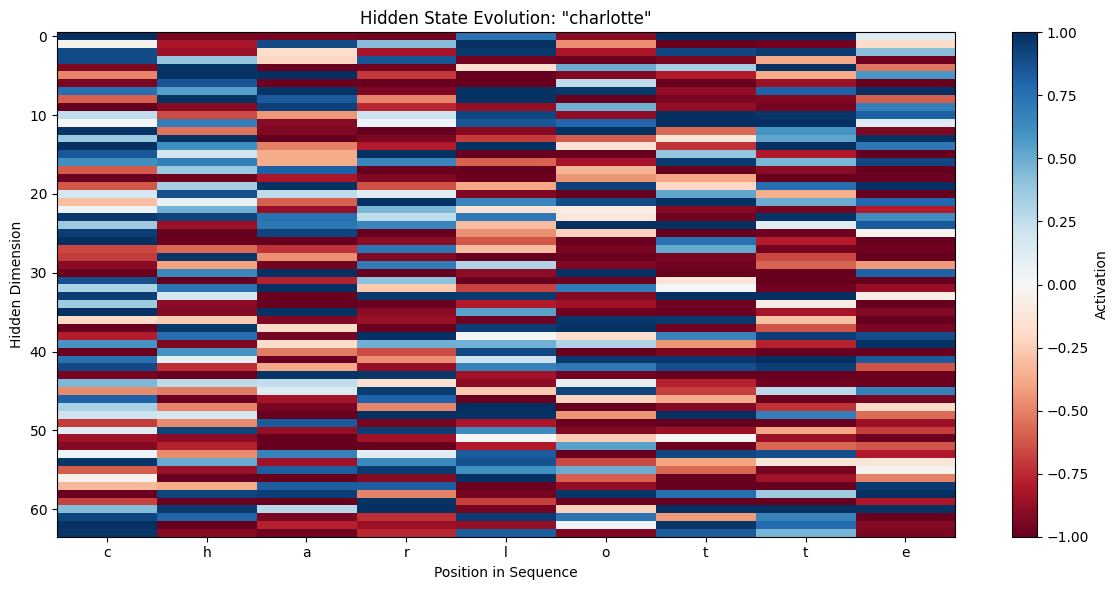

Each column shows the hidden state after processing that character.
Notice how patterns change as the network processes the sequence.


In [23]:
plt.figure(figsize=(12, 6))
plt.imshow(hidden_states.T, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar(label='Activation')
plt.xlabel('Position in Sequence')
plt.ylabel('Hidden Dimension')
plt.title(f'Hidden State Evolution: "{sample_name}"')
plt.xticks(range(len(sample_name)), list(sample_name))
plt.tight_layout()
plt.show()

print("Each column shows the hidden state after processing that character.")
print("Notice how patterns change as the network processes the sequence.")

## 12. The Vanishing Gradient Problem

RNNs have a fundamental limitation: **vanishing gradients**.

During backpropagation through time, gradients are multiplied at each time step. The $\tanh$ activation has derivatives in $(0, 1]$, so:

$$\text{gradient at } t=0 = \text{gradient at } t=T \times \prod_{i=1}^{T} \frac{\partial h_i}{\partial h_{i-1}}$$

For long sequences, this product becomes very small → early steps get tiny gradients → slow/no learning.

**Solutions:** LSTM and GRU architectures (covered in separate notebooks).

Let's demonstrate vanishing gradients by looking at gradient magnitudes.

In [24]:
# Create a long sequence
long_seq_len = 50
test_seq = torch.randint(0, vocab_size, (1, long_seq_len), device=device)
test_target = torch.randint(0, vocab_size, (1, long_seq_len), device=device)

# Forward and backward pass
model.zero_grad()
loss = compute_loss(model, test_seq, test_target)
loss.backward()

# Collect gradient norms
gradient_norms = []
for name, param in model.named_parameters():
    if param.grad is not None:
        gradient_norms.append((name, param.grad.norm().item()))

print("Gradient norms by layer:\n")
for name, norm in gradient_norms:
    print(f"  {name:30s}: {norm:.6f}")

print("\nNotice: Gradients flow through many time steps, but RNN structure helps maintain them.")
print("For very long sequences, gradients still tend to vanish.")

Gradient norms by layer:

  embedding.weight              : 0.385233
  rnn_cell.bias                 : 0.879064
  rnn_cell.W_ih.weight          : 1.551193
  rnn_cell.W_hh.weight          : 3.708504
  output_layer.weight           : 2.116483
  output_layer.bias             : 0.469951

Notice: Gradients flow through many time steps, but RNN structure helps maintain them.
For very long sequences, gradients still tend to vanish.


## 13. Comparison: PyTorch Built-in RNN

Our implementation matches PyTorch's built-in `nn.RNN`. Let's verify by comparing outputs.

In [25]:
class PyTorchRNN(nn.Module):
    """RNN using PyTorch's built-in implementation."""
    
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_size, batch_first=True)
        self.output_layer = nn.Linear(hidden_size, vocab_size)
    
    def forward(self, x, h=None):
        embeddings = self.embedding(x)
        output, h = self.rnn(embeddings, h)
        logits = self.output_layer(output)
        return logits, h

# Create PyTorch RNN
pytorch_model = PyTorchRNN(vocab_size, embedding_dim, hidden_size).to(device)

print("PyTorch built-in RNN:")
print(f"  Parameters: {sum(p.numel() for p in pytorch_model.parameters()):,}")
print(f"\nOur custom RNN:")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"\nBoth implementations are functionally equivalent!")

PyTorch built-in RNN:
  Parameters: 7,435

Our custom RNN:
  Parameters: 7,371

Both implementations are functionally equivalent!


Let's compare training speed between our implementation and PyTorch's.

In [26]:
import time

# Benchmark one epoch
def benchmark_model(model, train_loader, device, num_batches=10):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    start_time = time.time()
    for i, (x, y) in enumerate(train_loader):
        if i >= num_batches:
            break
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = compute_loss(model, x, y)
        loss.backward()
        optimizer.step()
    
    elapsed = time.time() - start_time
    return elapsed

custom_time = benchmark_model(model, train_loader, device)
pytorch_time = benchmark_model(pytorch_model, train_loader, device)

print(f"Custom RNN:   {custom_time:.3f}s")
print(f"PyTorch RNN:  {pytorch_time:.3f}s")
print(f"\nPyTorch is {custom_time/pytorch_time:.2f}x faster (optimized C++ backend)")

Custom RNN:   0.050s
PyTorch RNN:  0.066s

PyTorch is 0.75x faster (optimized C++ backend)


## 14. Key Takeaways

### Core Intuitions

1. **Hidden State = Memory**: RNNs maintain a hidden state that carries information through the sequence

2. **The RNN Formula**: $h_t = \tanh(W_{ih} x_t + W_{hh} h_{t-1} + b)$
   - Combines current input with previous memory
   - Applied recursively at each time step

3. **Backpropagation Through Time**: Gradients flow backward through all time steps
   - Enables learning from sequences
   - Challenges: vanishing/exploding gradients

4. **Temperature Controls Randomness**: Higher temperature → more creative, lower → more deterministic

5. **Vanishing Gradients**: Long sequences → tiny gradients → poor learning
   - Solution: LSTM/GRU architectures (covered elsewhere)

### What We Built

- ✅ RNN cell from scratch (matrix multiplications + tanh)
- ✅ Sequence processing (unrolling through time)
- ✅ Complete character-level language model
- ✅ Training loop with gradient clipping
- ✅ Text generation with temperature sampling
- ✅ Hidden state visualization

### Next Steps

- **LSTM**: Solves vanishing gradients with gating mechanisms
- **GRU**: Simplified LSTM variant
- **Bidirectional RNNs**: Process sequences forward and backward
- **Attention**: Learn which parts of the sequence matter most